# Credit Card Fraud Detection Using Deep Learning

This notebook walks through an end-to-end fraud detection project using the Kaggle `creditcard.csv` dataset.

## Workflow

1. Load the dataset
2. Clean the data and remove duplicates
3. Perform exploratory data analysis
4. Engineer features
5. Handle class imbalance with SMOTE
6. Train baseline machine learning models
7. Train a deep neural network
8. Compare model performance using fraud-focused metrics
9. Translate results into business impact


## Setup

Install the required packages before running the notebook:

```bash
pip install -r ../requirements.txt
```

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DEFAULT_DATA_PATH = PROJECT_ROOT / "data" / "creditcard.csv.zip"
FALLBACK_DATA_PATH = Path(r"D:\Project resume\2.Credit Card Fraud Detection\creditcard.csv.zip")
DATA_PATH = DEFAULT_DATA_PATH if DEFAULT_DATA_PATH.exists() else FALLBACK_DATA_PATH
FALSE_POSITIVE_COST = 25
FALSE_NEGATIVE_COST = 500
RANDOM_STATE = 42

FEATURE_COLUMNS = ["Time", "Amount", *[f"V{i}" for i in range(1, 29)]]
ENGINEERED_COLUMNS = ["LogAmount", "Hour", "DayIndex"]
MODEL_FEATURES = FEATURE_COLUMNS + ENGINEERED_COLUMNS

DATA_PATH


WindowsPath('D:/Project resume/2.Credit Card Fraud Detection/creditcard.csv.zip')

## Load and Clean Data

In [3]:
def load_dataset(dataset_path: Path) -> pd.DataFrame:
    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset not found at {dataset_path}")
    if dataset_path.suffix.lower() == ".zip":
        return pd.read_csv(dataset_path, compression="zip")
    return pd.read_csv(dataset_path)


def engineer_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    frame = dataframe.copy()
    frame["LogAmount"] = np.log1p(frame["Amount"].clip(lower=0))
    frame["Hour"] = ((frame["Time"] // 3600) % 24).astype(int)
    frame["DayIndex"] = (frame["Time"] // 86400).astype(int)
    return frame


raw_df = load_dataset(DATA_PATH)
duplicate_rows = int(raw_df.duplicated().sum())
missing_values = int(raw_df.isna().sum().sum())

clean_df = raw_df.drop_duplicates().copy()
clean_df["Class"] = clean_df["Class"].astype(int)
clean_df = engineer_features(clean_df)

quality_summary = pd.DataFrame(
    {
        "metric": [
            "Raw rows",
            "Clean rows",
            "Duplicate rows removed",
            "Missing values",
            "Fraud transactions",
            "Fraud rate (%)",
        ],
        "value": [
            len(raw_df),
            len(clean_df),
            duplicate_rows,
            missing_values,
            int(clean_df["Class"].sum()),
            round(clean_df["Class"].mean() * 100, 4),
        ],
    }
)
quality_summary


,metric,value
0,Raw rows,284807.0000
1,Clean rows,283726.0000
2,Duplicate rows removed,1081.0000
3,Missing values,0.0000
4,Fraud transactions,473.0000
5,Fraud rate (%),0.1667


## Exploratory Data Analysis

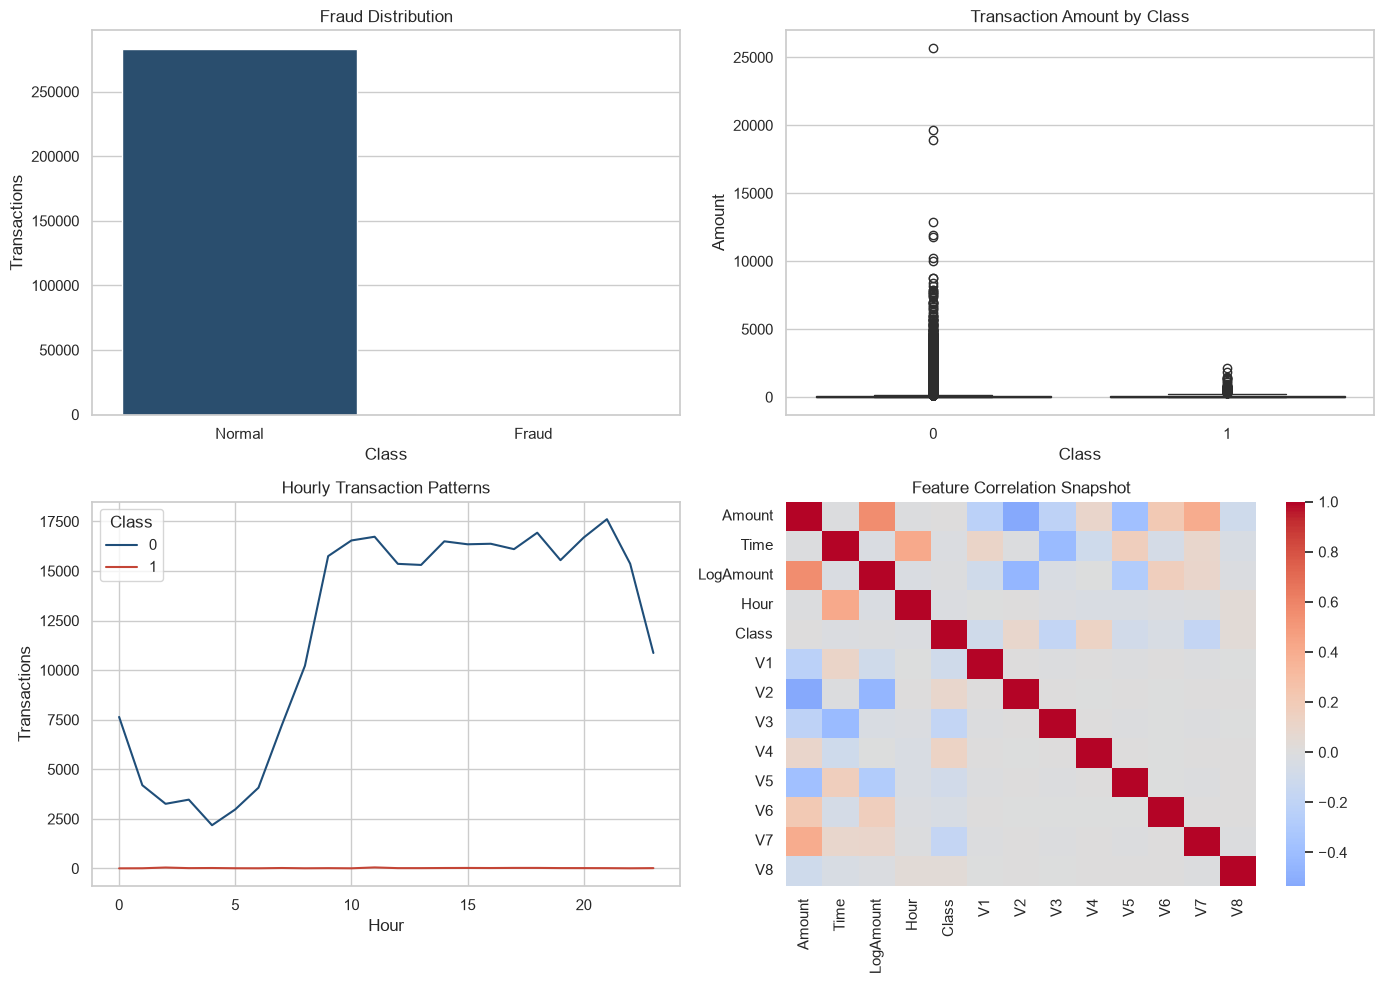

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

class_counts = clean_df["Class"].value_counts().rename(index={0: "Normal", 1: "Fraud"})
sns.barplot(x=class_counts.index, y=class_counts.values, palette=["#1f4e79", "#c44536"], ax=axes[0, 0])
axes[0, 0].set_title("Fraud Distribution")
axes[0, 0].set_ylabel("Transactions")

sns.boxplot(data=clean_df, x="Class", y="Amount", palette=["#1f4e79", "#c44536"], ax=axes[0, 1])
axes[0, 1].set_title("Transaction Amount by Class")

hourly = clean_df.groupby(["Hour", "Class"]).size().reset_index(name="Transactions")
sns.lineplot(data=hourly, x="Hour", y="Transactions", hue="Class", palette=["#1f4e79", "#c44536"], ax=axes[1, 0])
axes[1, 0].set_title("Hourly Transaction Patterns")

corr_subset = clean_df[["Amount", "Time", "LogAmount", "Hour", "Class", *[f"V{i}" for i in range(1, 9)]]].corr(numeric_only=True)
sns.heatmap(corr_subset, cmap="coolwarm", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Feature Correlation Snapshot")

plt.tight_layout()


In [5]:
eda_summary = pd.DataFrame(
    {
        "metric": [
            "Average amount",
            "Median amount",
            "Max amount",
            "Unique hours with fraud",
            "Total days in data",
        ],
        "value": [
            round(clean_df["Amount"].mean(), 2),
            round(clean_df["Amount"].median(), 2),
            round(clean_df["Amount"].max(), 2),
            int(clean_df.loc[clean_df["Class"] == 1, "Hour"].nunique()),
            int(clean_df["DayIndex"].nunique()),
        ],
    }
)
eda_summary


,metric,value
0,Average amount,88.47
1,Median amount,22.00
2,Max amount,25691.16
3,Unique hours with fraud,24.00
4,Total days in data,2.00


## EDA Visuals

The notebook can also display the saved charts generated by the analysis pipeline:

- Fraud Distribution
- Amount by Class
- Hourly Pattern
- Correlation Heatmap


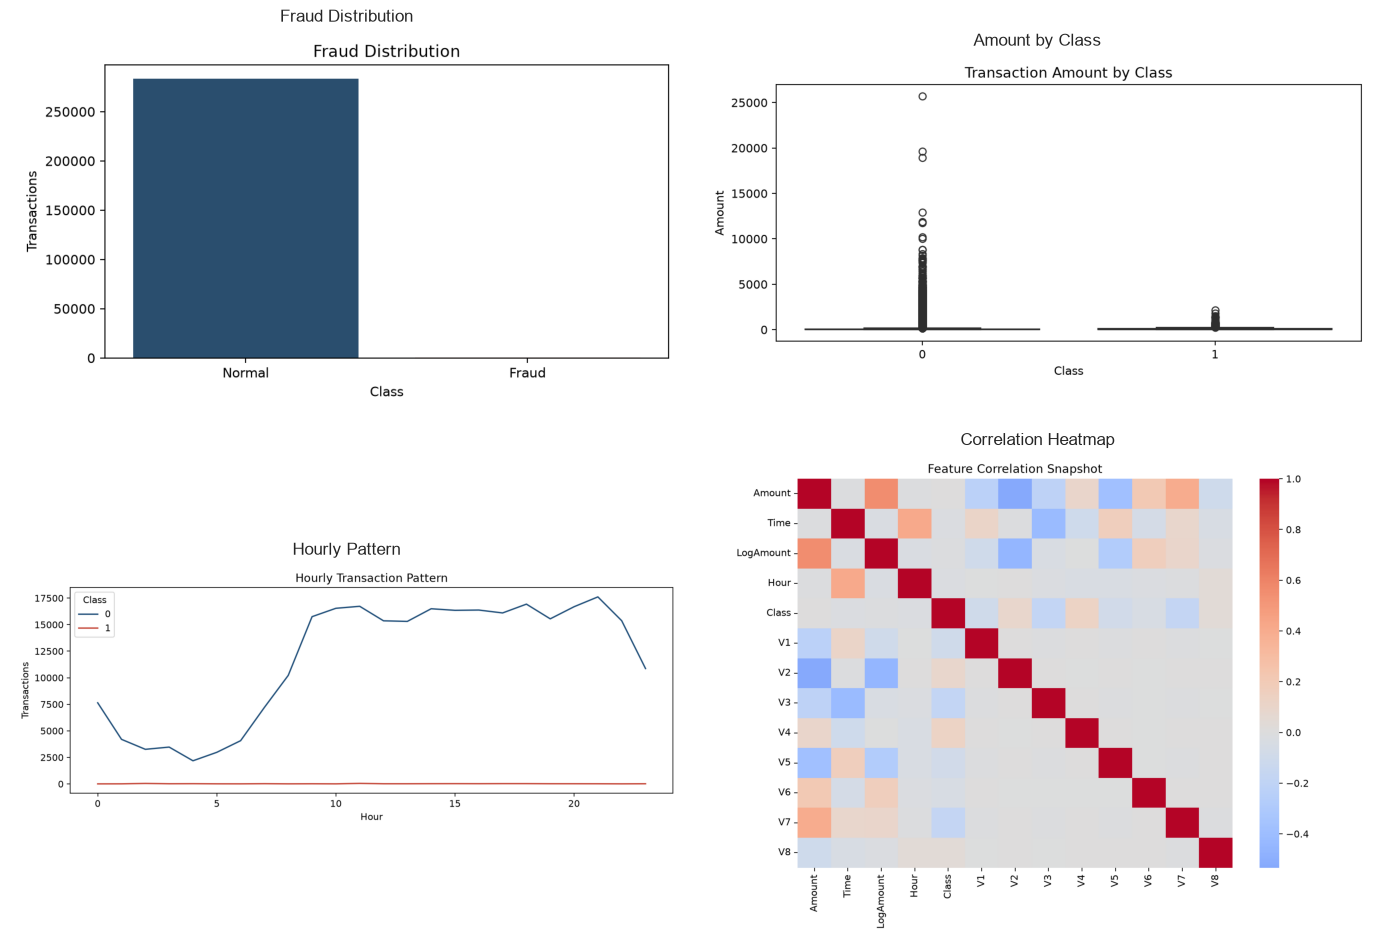

In [6]:
figure_dir = PROJECT_ROOT / "output" / "figures"
figure_specs = [
    ("Fraud Distribution", "fraud_distribution.png"),
    ("Amount by Class", "amount_by_class.png"),
    ("Hourly Pattern", "hourly_pattern.png"),
    ("Correlation Heatmap", "correlation_heatmap.png"),
]

missing_figures = [name for _, name in figure_specs if not (figure_dir / name).exists()]
if missing_figures:
    print("Missing figure files:", ", ".join(missing_figures))
    print("Run the training pipeline first to generate the charts inside output/figures.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for axis, (title, file_name) in zip(axes.flatten(), figure_specs):
        image = plt.imread(figure_dir / file_name)
        axis.imshow(image)
        axis.set_title(title)
        axis.axis("off")
    plt.tight_layout()


## Additional Visual Exploration

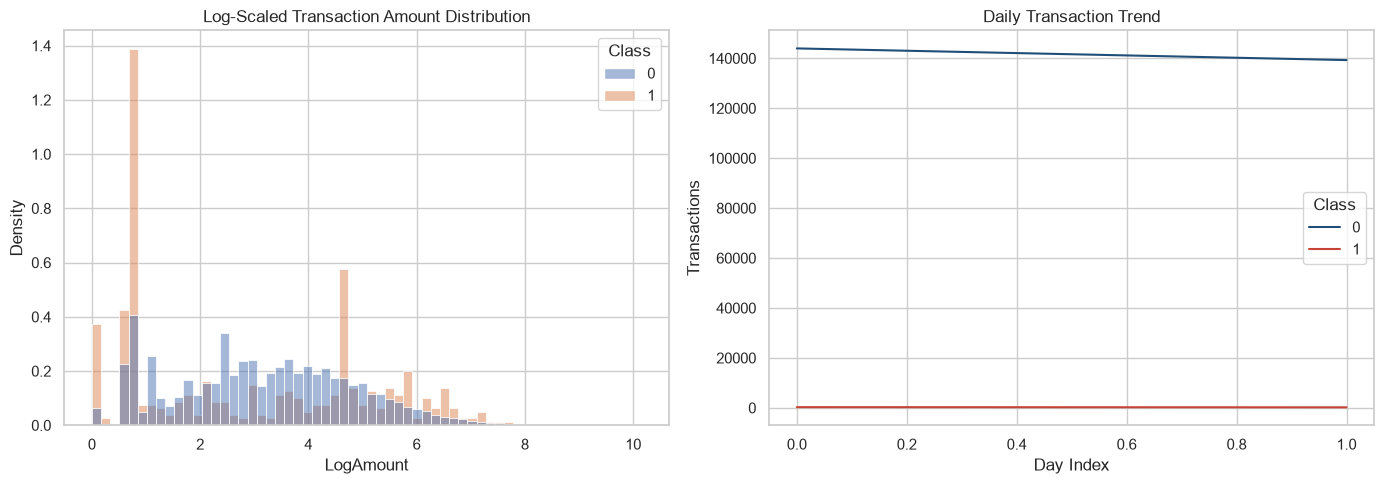

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=clean_df, x="LogAmount", hue="Class", bins=60, stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Log-Scaled Transaction Amount Distribution")

daily_fraud = clean_df.groupby(["DayIndex", "Class"]).size().reset_index(name="Transactions")
sns.lineplot(data=daily_fraud, x="DayIndex", y="Transactions", hue="Class", palette=["#1f4e79", "#c44536"], ax=axes[1])
axes[1].set_title("Daily Transaction Trend")
axes[1].set_xlabel("Day Index")

plt.tight_layout()


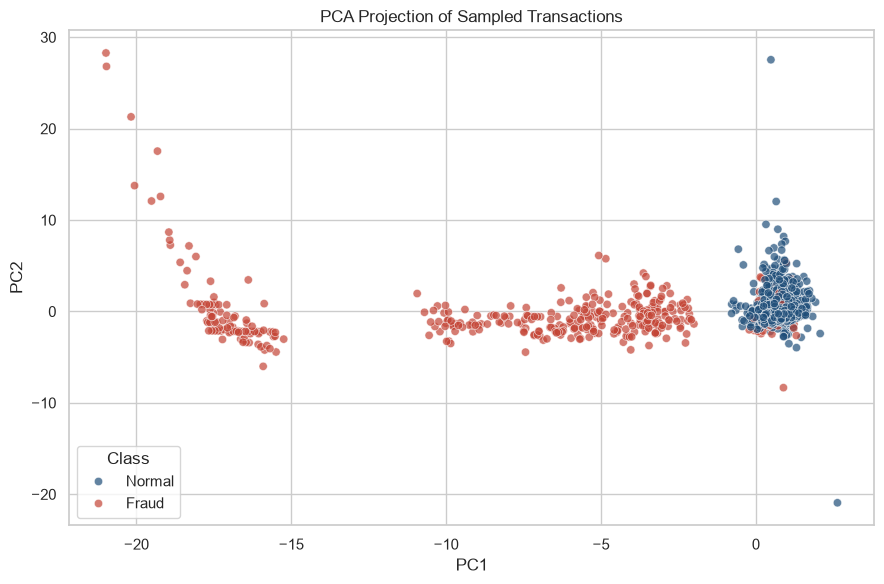

In [8]:
pca_features = clean_df[["Amount", "LogAmount", *[f"V{i}" for i in range(1, 29)]]].copy()
sample_df = pd.concat(
    [
        clean_df.loc[clean_df["Class"] == 0].sample(4000, random_state=RANDOM_STATE),
        clean_df.loc[clean_df["Class"] == 1],
    ],
    axis=0,
).sample(frac=1, random_state=RANDOM_STATE)

sample_features = sample_df[["Amount", "LogAmount", *[f"V{i}" for i in range(1, 29)]]]
sample_scaled = StandardScaler().fit_transform(sample_features)
pca_projection = PCA(n_components=2, random_state=RANDOM_STATE)
projection = pca_projection.fit_transform(sample_scaled)

projection_df = pd.DataFrame(
    {
        "PC1": projection[:, 0],
        "PC2": projection[:, 1],
        "Class": sample_df["Class"].map({0: "Normal", 1: "Fraud"}).values,
    }
)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=projection_df, x="PC1", y="PC2", hue="Class", alpha=0.7, palette=["#1f4e79", "#c44536"])
plt.title("PCA Projection of Sampled Transactions")
plt.tight_layout()


## Train, Validation, and Test Split

In [9]:
X = clean_df[MODEL_FEATURES].copy()
y = clean_df["Class"].copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(X_train), len(X_valid), len(X_test)],
        "fraud_rate_pct": [
            round(y_train.mean() * 100, 4),
            round(y_valid.mean() * 100, 4),
            round(y_test.mean() * 100, 4),
        ],
    }
)
split_summary


,split,rows,fraud_rate_pct
0,train,170235,0.1668
1,validation,56745,0.1657
2,test,56746,0.1674


## Helper Functions for Modeling

In [10]:
def smote_resample(features: pd.DataFrame, target: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
    sampler = SMOTE(random_state=RANDOM_STATE)
    X_resampled, y_resampled = sampler.fit_resample(features, target)
    return pd.DataFrame(X_resampled, columns=features.columns), pd.Series(y_resampled, name=target.name)


def find_best_threshold(y_true: pd.Series, probabilities: np.ndarray) -> tuple[float, float]:
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    if len(thresholds) == 0:
        return 0.5, 0.0
    precision = precision[:-1]
    recall = recall[:-1]
    f1_scores = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) != 0,
    )
    best_idx = int(f1_scores.argmax())
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


def evaluate_predictions(model_name: str, y_true: pd.Series, probabilities: np.ndarray, threshold: float) -> dict:
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()
    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1_score": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "estimated_cost": (fp * FALSE_POSITIVE_COST) + (fn * FALSE_NEGATIVE_COST),
    }


## Baseline Models

In [11]:
X_train_smote, y_train_smote = smote_resample(X_train, y_train)

logistic_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)
logistic_pipeline.fit(X_train_smote, y_train_smote)

logistic_valid_probs = logistic_pipeline.predict_proba(X_valid)[:, 1]
logistic_threshold, logistic_valid_f1 = find_best_threshold(y_valid, logistic_valid_probs)
logistic_test_probs = logistic_pipeline.predict_proba(X_test)[:, 1]
logistic_metrics = evaluate_predictions("Logistic Regression + SMOTE", y_test, logistic_test_probs, logistic_threshold)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

rf_valid_probs = rf_model.predict_proba(X_valid)[:, 1]
rf_threshold, rf_valid_f1 = find_best_threshold(y_valid, rf_valid_probs)
rf_test_probs = rf_model.predict_proba(X_test)[:, 1]
rf_metrics = evaluate_predictions("Random Forest", y_test, rf_test_probs, rf_threshold)

baseline_results = pd.DataFrame([logistic_metrics, rf_metrics]).sort_values(["estimated_cost", "pr_auc"], ascending=[True, False])
baseline_results.round(4)


  File "C:\Users\sidka\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,model,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive,estimated_cost
0,Logistic Regression + SMOTE,1.0000,0.9994,0.8750,0.7368,0.8000,0.9654,0.7042,56641,10,25,70,12750
1,Random Forest,0.6285,0.9994,0.9437,0.7053,0.8072,0.9464,0.8020,56647,4,28,67,14100


## Deep Neural Network

In [12]:
tf.keras.utils.set_random_seed(RANDOM_STATE)

dl_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

X_train_dl_smote, y_train_dl_smote = smote_resample(X_train, y_train)
X_train_processed = dl_preprocessor.fit_transform(X_train_dl_smote)
X_valid_processed = dl_preprocessor.transform(X_valid)
X_test_processed = dl_preprocessor.transform(X_test)

class_weight = {
    0: 1.0,
    1: max(1.0, (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)),
}

neural_network = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train_processed.shape[1],)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.30),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.20),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

neural_network.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

history = neural_network.fit(
    X_train_processed,
    y_train_dl_smote,
    validation_data=(X_valid_processed, y_valid),
    epochs=40,
    batch_size=1024,
    verbose=1,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=5,
            restore_best_weights=True,
        )
    ],
)


Epoch 1/40


  1/332 ━━━━━━━━━━━━━━━━━━━━ 16:17 3s/step - loss: 103.2898 - pr_auc: 0.6205 - precision: 0.5230 - recall: 0.9049 - roc_auc: 0.5988

 11/332 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 57.4071 - pr_auc: 0.8464 - precision: 0.5736 - recall: 0.9669 - roc_auc: 0.8384   

 21/332 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 38.1100 - pr_auc: 0.9004 - precision: 0.5751 - recall: 0.9806 - roc_auc: 0.8938

 31/332 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 28.3402 - pr_auc: 0.9178 - precision: 0.5700 - recall: 0.9866 - roc_auc: 0.9113

...

298/332 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0409 - pr_auc: 0.9960 - precision: 0.9850 - recall: 1.0000 - roc_auc: 0.9980

309/332 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0410 - pr_auc: 0.9959 - precision: 0.9851 - recall: 1.0000 - roc_auc: 0.9980

320/332 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0410 - pr_auc: 0.9960 - precision: 0.9853 - recall: 1.0000 - roc_auc: 0.9980

332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0410 - pr_auc: 0.9959 - precision: 0.9853 - recall: 1.0000 - roc_auc: 0.9980

332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0410 - pr_auc: 0.9959 - precision: 0.9853 - recall: 1.0000 - roc_auc: 0.9980 - val_loss: 0.0368 - val_pr_auc: 0.3098 - val_precision: 0.1775 - val_recall: 0.9043 - val_roc_auc: 0.9549


In [13]:
dl_valid_probs = neural_network.predict(X_valid_processed, verbose=0).ravel()
dl_threshold, dl_valid_f1 = find_best_threshold(y_valid, dl_valid_probs)
dl_test_probs = neural_network.predict(X_test_processed, verbose=0).ravel()
dl_metrics = evaluate_predictions("Deep Neural Network", y_test, dl_test_probs, dl_threshold)

results_df = pd.DataFrame([logistic_metrics, rf_metrics, dl_metrics]).sort_values(["estimated_cost", "pr_auc"], ascending=[True, False])
results_df.round(4)


,model,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive,estimated_cost
0,Logistic Regression + SMOTE,1.0000,0.9994,0.8750,0.7368,0.8000,0.9654,0.7042,56641,10,25,70,12750
1,Random Forest,0.6285,0.9994,0.9437,0.7053,0.8072,0.9464,0.8020,56647,4,28,67,14100
2,Deep Neural Network,1.0000,0.9992,0.8049,0.6947,0.7458,0.9641,0.6915,56635,16,29,66,14900


## Model Comparison Visuals

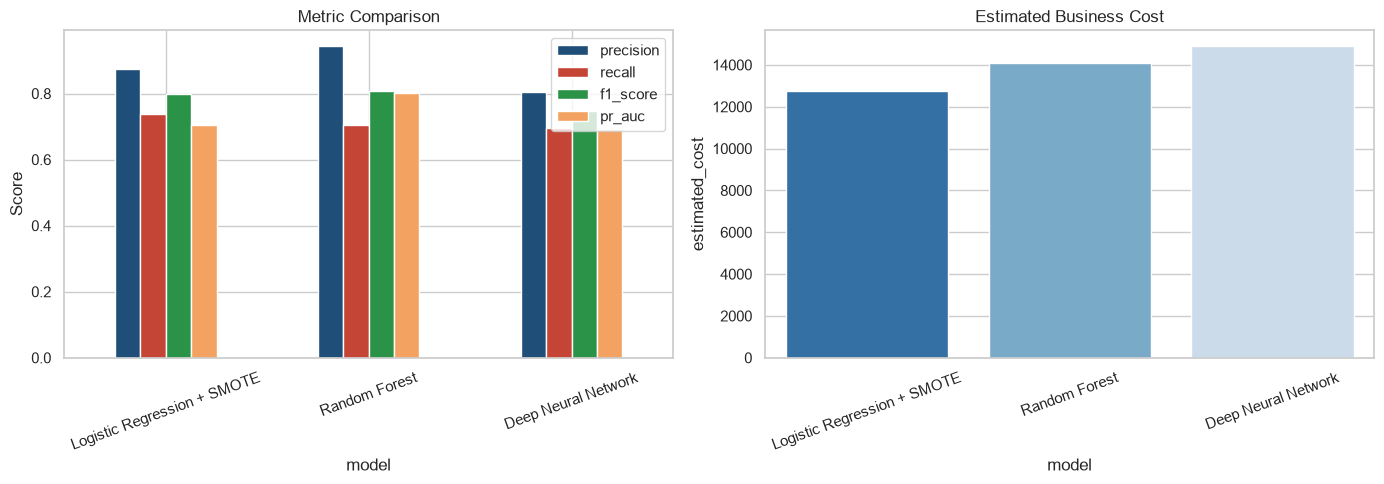

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = results_df[["model", "precision", "recall", "f1_score", "pr_auc"]].set_index("model")
plot_df.plot(kind="bar", ax=axes[0], color=["#1f4e79", "#c44536", "#2b9348", "#f4a261"])
axes[0].set_title("Metric Comparison")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=results_df, x="model", y="estimated_cost", palette="Blues_r", ax=axes[1])
axes[1].set_title("Estimated Business Cost")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()


## Evaluation Curves and Confusion Matrices

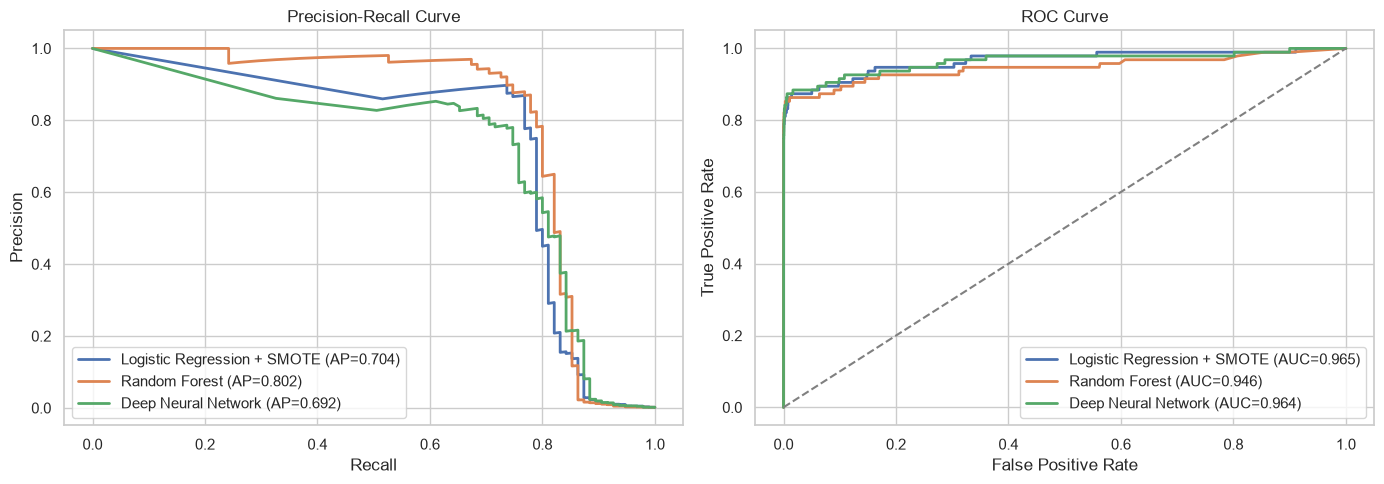

In [15]:
model_outputs = {
    "Logistic Regression + SMOTE": (logistic_test_probs, logistic_threshold),
    "Random Forest": (rf_test_probs, rf_threshold),
    "Deep Neural Network": (dl_test_probs, dl_threshold),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, (probabilities, _) in model_outputs.items():
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    axes[0].plot(recall, precision, linewidth=2, label=f"{model_name} (AP={average_precision_score(y_test, probabilities):.3f})")

axes[0].set_title("Precision-Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend()

for model_name, (probabilities, _) in model_outputs.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    axes[1].plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={roc_auc_score(y_test, probabilities):.3f})")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()


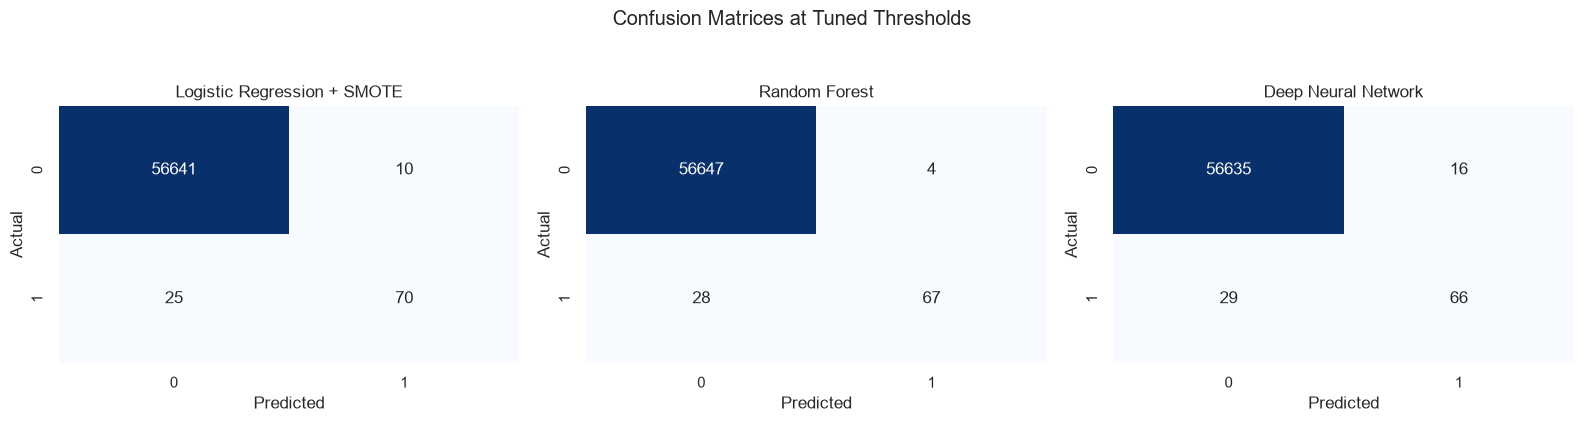

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for axis, (model_name, (probabilities, threshold)) in zip(axes, model_outputs.items()):
    predicted = (probabilities >= threshold).astype(int)
    matrix = confusion_matrix(y_test, predicted)
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set_title(model_name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")

plt.suptitle("Confusion Matrices at Tuned Thresholds", y=1.05)
plt.tight_layout()


## Neural Network Training Curves

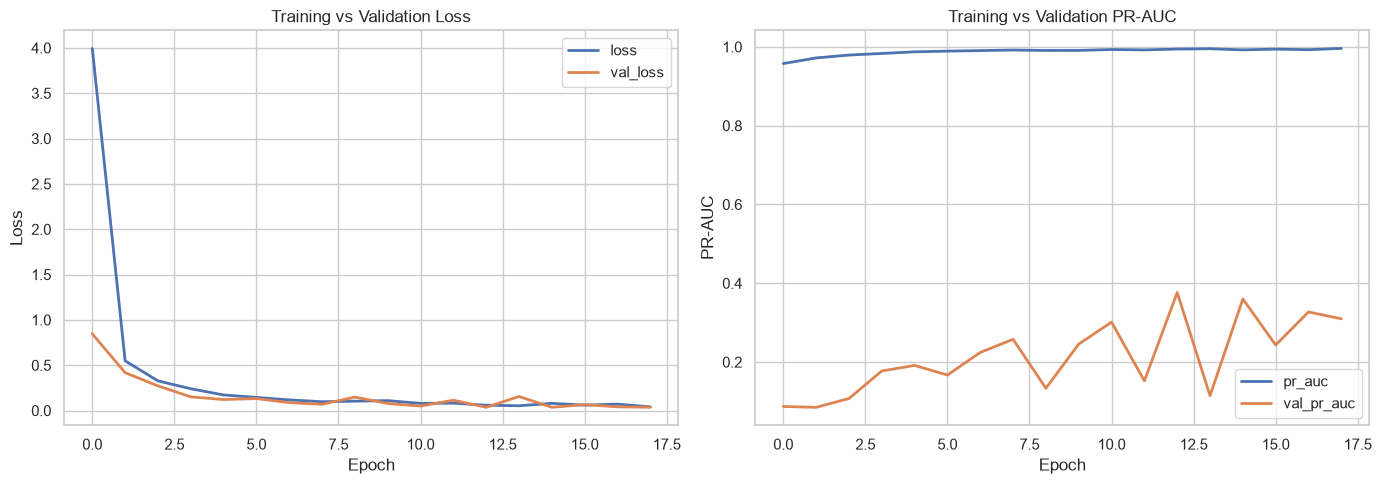

In [17]:
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history_df[["loss", "val_loss"]].plot(ax=axes[0], linewidth=2)
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

history_df[["pr_auc", "val_pr_auc"]].plot(ax=axes[1], linewidth=2)
axes[1].set_title("Training vs Validation PR-AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("PR-AUC")

plt.tight_layout()


## Business Interpretation

In [18]:
best_model = results_df.iloc[0]

business_summary = pd.DataFrame(
    {
        "recommended_model": [best_model["model"]],
        "precision": [round(best_model["precision"], 4)],
        "recall": [round(best_model["recall"], 4)],
        "false_positive": [int(best_model["false_positive"])],
        "false_negative": [int(best_model["false_negative"])],
        "estimated_cost": [round(best_model["estimated_cost"], 2)],
    }
)
business_summary


,recommended_model,precision,recall,false_positive,false_negative,estimated_cost
0,Logistic Regression + SMOTE,0.875,0.7368,10,25,12750


### Key Takeaways

- Accuracy alone is misleading because fraud is extremely rare.
- Precision and recall provide a better picture of review workload and fraud capture.
- PR-AUC is especially useful because it focuses on the minority class.
- Threshold tuning changes the business outcome more than a small change in raw accuracy.
- False negatives usually cost far more than false positives in fraud operations.


## Optional Save Step

Use this if you want to export notebook results as CSV files.

In [19]:
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

quality_summary.to_csv(OUTPUT_DIR / "notebook_data_quality_summary.csv", index=False)
eda_summary.to_csv(OUTPUT_DIR / "notebook_eda_summary.csv", index=False)
results_df.to_csv(OUTPUT_DIR / "notebook_model_comparison.csv", index=False)
business_summary.to_csv(OUTPUT_DIR / "notebook_business_summary.csv", index=False)

print("Notebook outputs saved to:", OUTPUT_DIR)


Notebook outputs saved to: C:\Users\sidka\OneDrive - St. Clair College\Documents\resume projects\credit_card_fraud_detection_deep_learning\output
